<a href="https://colab.research.google.com/github/Taqwa10/Codveda-Data-Analysis-Internship/blob/main/Analyzing_Stock_Price_Trends_Over_Time.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Codveda Task: Level 2**

## Task 1: Time Series Analysis of Stock Prices
## **Project Overview**

This project performs a time series analysis on a cleaned stock price dataset prepared during the Data Cleaning and Preprocessing phase. The objective is to analyze the historical stock prices of a selected company by identifying long-term trends, seasonal patterns, and random fluctuations. The analysis includes time series visualization, seasonal decomposition using statsmodels, and moving average smoothing to better understand stock price behavior over time.


## Dataset Description

The dataset contains historical daily stock market data for multiple publicly traded companies. Each record represents the trading activity of a company's stock on a specific date.

The dataset includes the following variables:

- **Date:** The trading date.
- **Symbol:** The stock ticker representing each company.
- **Open:** The opening stock price for the trading day.
- **High:** The highest stock price reached during the day.
- **Low:** The lowest stock price reached during the day.
- **Close:** The closing stock price for the trading day.
- **Volume:** The total number of shares traded during the day.

For this analysis, a single company's stock data will be selected to perform time series analysis on its closing prices over time.
## Tools Used

  Python - Google Colab - Pandas - Matplotlib - Statsmodels

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving cleaned_stock_data.csv to cleaned_stock_data.csv


In [ ]:
stock = pd.read_csv("cleaned_stock_data.csv")

In [ ]:
stock.info()
print("Dataset Shape:", stock.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  object 
 1   date    497472 non-null  object 
 2   open    497472 non-null  float64
 3   high    497472 non-null  float64
 4   low     497472 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 26.6+ MB
Dataset Shape: (497472, 7)


In [ ]:
#Select data for a specific company, e.g., 'AAPL'
stock = stock[stock['symbol'] == 'AAPL'].copy()

print(f"Selected data for company: 'AAPL'")
stock.head()

Selected data for company: 'AAPL'


,symbol,date,open,high,low,close,volume
3021,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
3022,AAPL,2014-01-03,78.9799,79.0999,77.2042,77.2828,98303870
3023,AAPL,2014-01-06,76.7785,78.1142,76.2285,77.7042,103359151
3024,AAPL,2014-01-07,77.7599,77.9942,76.8464,77.1481,79432766
3025,AAPL,2014-01-08,76.9728,77.9371,76.9556,77.6371,64686685


In [ ]:
# Sort the DataFrame by 'date' Chronologically
stock = stock.sort_values('date')

print("DataFrame sorted chronologically by 'date' column.")
display(stock.head())

DataFrame sorted chronologically by 'date' column.


,symbol,date,open,high,low,close,volume
3021,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
3022,AAPL,2014-01-03,78.9799,79.0999,77.2042,77.2828,98303870
3023,AAPL,2014-01-06,76.7785,78.1142,76.2285,77.7042,103359151
3024,AAPL,2014-01-07,77.7599,77.9942,76.8464,77.1481,79432766
3025,AAPL,2014-01-08,76.9728,77.9371,76.9556,77.6371,64686685


In [ ]:
# Set the 'date' column as the index
stock.set_index('date', inplace=True)

print("Date column set as DataFrame index.")
display(stock.head())

Date column set as DataFrame index.


,symbol,open,high,low,close,volume
date,,,,,,
2014-01-02,AAPL,79.3828,79.5756,78.8601,79.0185,58791957
2014-01-03,AAPL,78.9799,79.0999,77.2042,77.2828,98303870
2014-01-06,AAPL,76.7785,78.1142,76.2285,77.7042,103359151
2014-01-07,AAPL,77.7599,77.9942,76.8464,77.1481,79432766
2014-01-08,AAPL,76.9728,77.9371,76.9556,77.6371,64686685


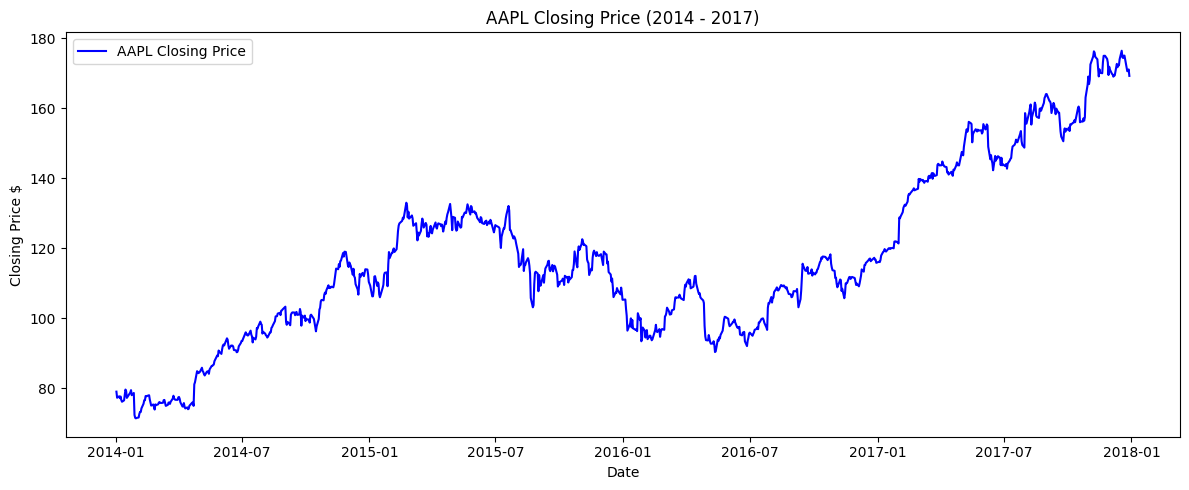

In [ ]:
#Plot Time-Series Data and Identify Patterns
plt.figure(figsize=(12,5))

stock.index = pd.to_datetime(stock.index)

plt.plot(stock.index, stock['close'],label='AAPL Closing Price', color='blue')

plt.title("AAPL Closing Price (2014 - 2017)")
plt.xlabel("Date")
plt.ylabel("Closing Price $")
plt.legend()
plt.tight_layout()
plt.show()

We analyzed the closing price because it represents the final market price of each trading day.
The closing price shows fluctuations throughout the period. The overall movement indicates the long-term trend of the stock, while short-term variations represent daily market volatility.

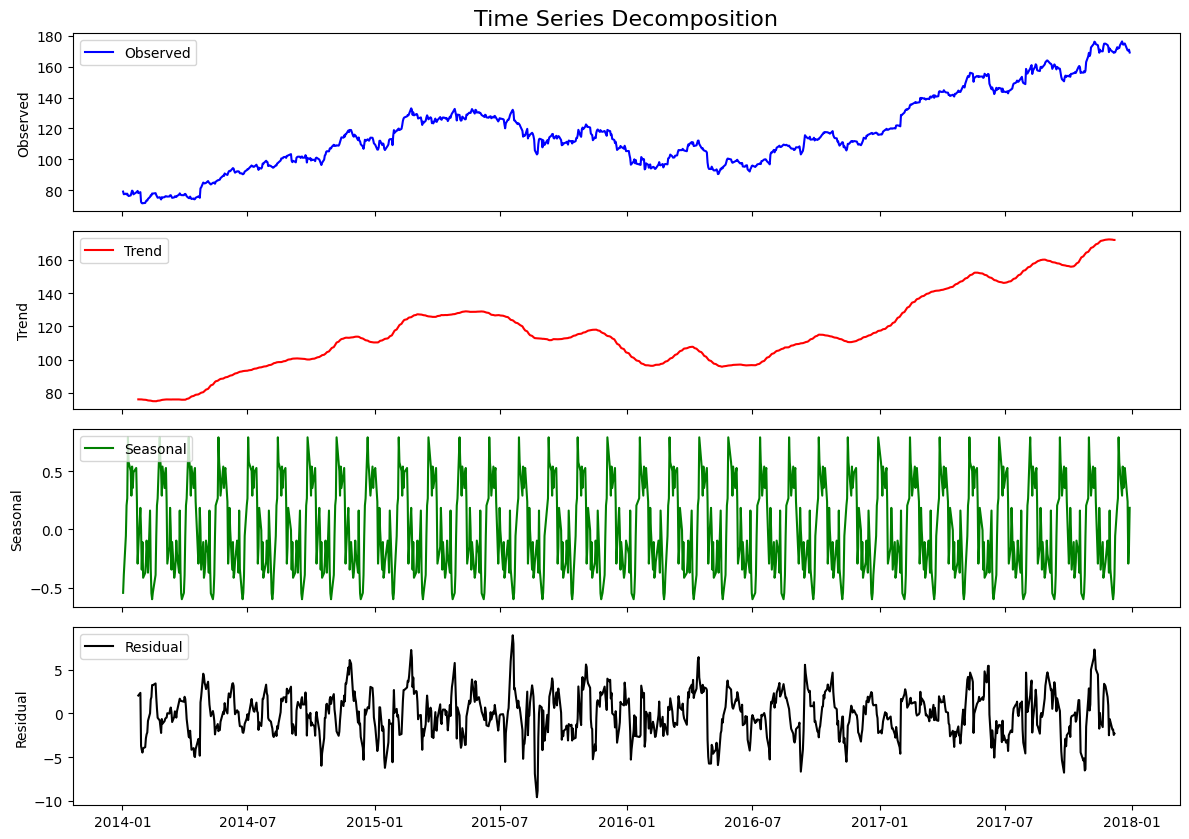

In [ ]:
#Decompose the Series into Trend, Seasonality, and Residuals
decomposition = seasonal_decompose(stock['close'], model='additive', period=30)

# Create a figure with 4 subplots
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

# Observed data
ax1.plot(decomposition.observed, color='blue', label='Observed')
ax1.set_title('Time Series Decomposition', y=1, fontsize=16)
ax1.set_ylabel('Observed')
ax1.legend(loc='upper left')

# Trend component
ax2.plot(decomposition.trend, color='red', label='Trend')
ax2.set_ylabel('Trend')
ax2.legend(loc='upper left')

# Seasonal component
ax3.plot(decomposition.seasonal, color='green', label='Seasonal')
ax3.set_ylabel('Seasonal')
ax3.legend(loc='upper left')

# Residual component
ax4.plot(decomposition.resid, color='black', label='Residual')
ax4.set_ylabel('Residual')
ax4.legend(loc='upper left')

plt.tight_layout(rect=[0, 0.03, 1, 0.88])
plt.show()

The trend component highlights the general direction of the stock price over time. The seasonal component shows limited repeating behavior, which is expected because stock prices are influenced by unpredictable market conditions. The residual component represents random price movements.

In [ ]:
#Calculate 30-day Moving Average
stock['MA30'] = (stock['close'] .rolling(window=30) .mean())
stock['MA90'] = (stock['close'] .rolling(window=90) .mean())
stock.head()

,symbol,open,high,low,close,volume,MA30,MA90
date,,,,,,,,
2014-01-02,AAPL,79.3828,79.5756,78.8601,79.0185,58791957,NaN,NaN
2014-01-03,AAPL,78.9799,79.0999,77.2042,77.2828,98303870,NaN,NaN
2014-01-06,AAPL,76.7785,78.1142,76.2285,77.7042,103359151,NaN,NaN
2014-01-07,AAPL,77.7599,77.9942,76.8464,77.1481,79432766,NaN,NaN
2014-01-08,AAPL,76.9728,77.9371,76.9556,77.6371,64686685,NaN,NaN


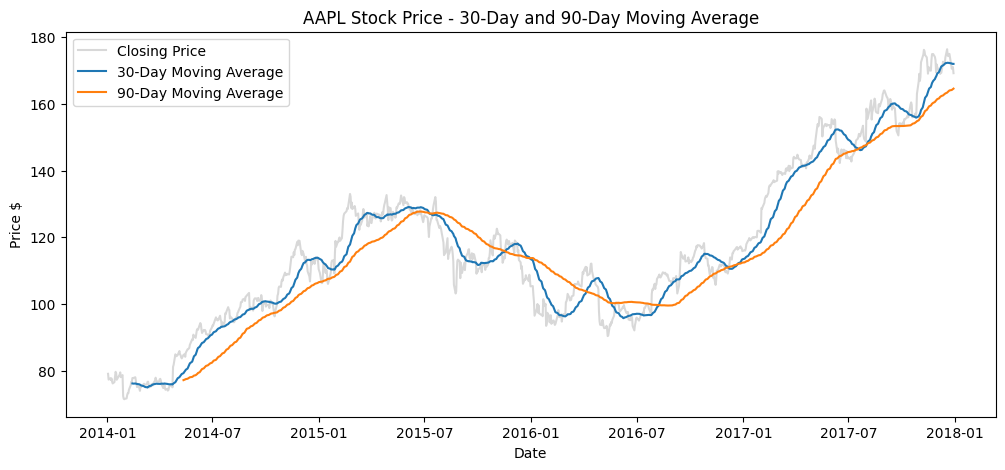

In [ ]:
#Plot Original Price vs Moving Average
plt.figure(figsize=(12,5))

plt.plot(stock.index,stock['close'],label="Closing Price", alpha=0.3, color='gray')
plt.plot(stock.index,stock['MA30'],label="30-Day Moving Average")
plt.plot(stock.index,stock['MA90'],label="90-Day Moving Average")


plt.title("AAPL Stock Price - 30-Day and 90-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Price $")
plt.legend()

plt.show()

The moving average smooths short-term fluctuations and reveals the overall direction of the stock price. Periods where the moving average increases indicate positive momentum, while decreases suggest downward movement.

##Key Insights
The closing stock price exhibited fluctuations over the analyzed time period.
The time series visualization revealed the overall movement of the stock price over time.
Seasonal decomposition separated the data into trend, seasonal, and residual components, making it easier to analyze the underlying patterns.
The seasonal component showed no strong recurring pattern during the analyzed period.
The 30-day moving average smoothed short-term fluctuations and highlighted the overall trend in the stock price.